# **Evaluacion 3: Programación en Ciencia de Datos - Car Seats**

**Integrantes del Grupo:**
1. Felipe Araya
2. Antonia Muñoz
3. Sofia Cortese

In [136]:
# Importando Librerías
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# Instalación de dependencias para el Dashboard
import sys
!{sys.executable} -m pip install dash plotly --quiet

sns.set_theme(style="whitegrid")
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 1. Extracción de Datos (Ingesta)

Se extraen los datos desde el archivo CSV local y se obtiene el tipo de cambio actualizado mediante la API REST.

In [137]:
# Lectura del archivo directo en Colab
df_sales = pd.read_csv('dataset_car_seats.csv')
df_sales.shape

(400, 12)

In [138]:
# Vista general del dataset
df_sales.head()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


> ## Extraer de JSON a través de API
Tanto JSON como XML son formatos comunes para almacenar datos. Extraeremos el valor de cotización actual del dólar desde una API pública.

In [139]:
url_api = "https://cl.dolarapi.com/v1/cotizaciones/usd"
response = requests.get(url_api)

if response.status_code == 200:
    data_api = response.json()
    # La API puede devolver el valor como string o como 0; lo casteamos y validamos
    raw_value = data_api.get('venta', 0)
    usd_value = float(raw_value) if float(raw_value) > 0 else None

    if usd_value and usd_value > 0:
        print(f"Valor del dólar obtenido desde API: ${usd_value:,.2f} CLP")
    else:
        usd_value = 950.0
        print(f"API devolvió valor inválido ({raw_value}), usando valor de respaldo: ${usd_value}")
else:
    usd_value = 950.0
    print(f"Error conectando a la API (status {response.status_code}), usando valor de respaldo: ${usd_value}")

print(f"Tipo de cambio a usar: 1 USD = ${usd_value:,.2f} CLP")

API devolvió valor inválido (0), usando valor de respaldo: $950.0
Tipo de cambio a usar: 1 USD = $950.00 CLP


# 2. Transformar

Primero se realiza la conversión de moneda a pesos chilenos y luego se crea la variable objetivo `HighSales`.

In [140]:
# Guardar copia de los valores originales antes de transformar
df_sales_raw = df_sales.copy()

# Verificar que el tipo de cambio es válido antes de transformar
if usd_value <= 0:
    raise ValueError(f"Tipo de cambio inválido: {usd_value}. Revisar celda de la API.")

# 1. Transformación de moneda (Dólares a CLP) — PRIMERO la conversión
# Price y CompPrice son valores directos en USD.
# Income y Advertising están en miles de USD.
cols_directas = ['Price', 'CompPrice']
cols_miles    = ['Income', 'Advertising']

for col in cols_directas:
    if col in df_sales.columns:
        df_sales[col] = round(df_sales[col] * usd_value, 0)

for col in cols_miles:
    if col in df_sales.columns:
        df_sales[col] = round((df_sales[col] * 1000) * usd_value, 0)

# 2. Crear variable booleana HighSales (> 8) — DESPUÉS de la conversión
df_sales['HighSales'] = (df_sales['Sales'] > 8).astype(int)

# Verificación de la transformación
print(f"Tipo de cambio aplicado: 1 USD = ${usd_value:,.2f} CLP")
print(f"Price range: ${df_sales['Price'].min():,.0f} — ${df_sales['Price'].max():,.0f} CLP")
print(f"Income range: ${df_sales['Income'].min():,.0f} — ${df_sales['Income'].max():,.0f} CLP")
print(f"HighSales (ventas > 8 miles): {df_sales['HighSales'].sum()} tiendas de {len(df_sales)}")
df_sales[['Sales', 'HighSales', 'Price', 'Income', 'Advertising']].head()

Tipo de cambio aplicado: 1 USD = $950.00 CLP
Price range: $22,800 — $181,450 CLP
Income range: $19,950,000 — $114,000,000 CLP
HighSales (ventas > 8 miles): 164 tiendas de 400


,Sales,HighSales,Price,Income,Advertising
0,9.50,1,114000.0,69350000.0,10450000.0
1,11.22,1,78850.0,45600000.0,15200000.0
2,10.06,1,76000.0,33250000.0,9500000.0
3,7.40,0,92150.0,95000000.0,3800000.0
4,4.15,0,121600.0,60800000.0,2850000.0


# 3. Análisis Exploratorio de Datos (EDA)

Exploraremos las estadísticas descriptivas y visualizaremos el comportamiento de las variables más relevantes.

In [141]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   400 non-null    int64  
 1   Sales        400 non-null    float64
 2   CompPrice    400 non-null    float64
 3   Income       400 non-null    float64
 4   Advertising  400 non-null    float64
 5   Population   400 non-null    int64  
 6   Price        400 non-null    float64
 7   ShelveLoc    400 non-null    object 
 8   Age          400 non-null    int64  
 9   Education    400 non-null    int64  
 10  Urban        400 non-null    object 
 11  US           400 non-null    object 
 12  HighSales    400 non-null    int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 40.8+ KB


In [142]:
# Estadísticas descriptivas del conjunto de datos
df_sales.describe()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,HighSales
count,400.000000,400.000000,400.00000,4.000000e+02,4.000000e+02,400.000000,400.00000,400.000000,400.000000,400.000000
mean,199.500000,7.496325,118726.25000,6.522462e+07,6.303250e+06,264.840000,110005.25000,53.322500,13.900000,0.410000
std,115.614301,2.824115,14567.78593,2.658673e+07,6.317846e+06,147.376436,22492.83116,16.200297,2.620528,0.492449
min,0.000000,0.000000,73150.00000,1.995000e+07,0.000000e+00,10.000000,22800.00000,25.000000,10.000000,0.000000
25%,99.750000,5.390000,109250.00000,4.061250e+07,0.000000e+00,139.000000,95000.00000,39.750000,12.000000,0.000000
50%,199.500000,7.490000,118750.00000,6.555000e+07,4.750000e+06,272.000000,111150.00000,54.500000,14.000000,0.000000
75%,299.250000,9.320000,128250.00000,8.645000e+07,1.140000e+07,398.500000,124450.00000,66.000000,16.000000,1.000000
max,399.000000,16.270000,166250.00000,1.140000e+08,2.755000e+07,509.000000,181450.00000,80.000000,18.000000,1.000000


In [143]:
# Cuenta el número de valores nulos en las columnas del conjunto de datos
df_sales.isnull().sum()

,0
Unnamed: 0,0
Sales,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0


Se observa que no hay valores nulos en el conjunto de datos que deban resolverse.

### Visualizaciones del EDA

Los siguientes gráficos se realizan con `df_sales`, es decir, con los datos ya transformados a CLP pero **sin estandarizar**, para que los valores sean interpretables.

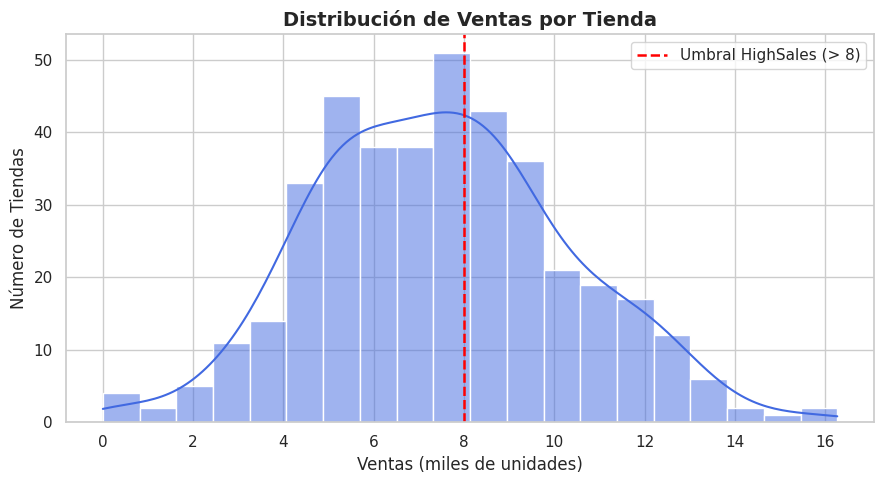

Ventas promedio: 7.50 | Mediana: 7.49
Tiendas con ventas altas (>8): 164 de 400


In [144]:
# Histograma de la variable objetivo (Sales) con umbral HighSales
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df_sales['Sales'], kde=True, color='royalblue', bins=20, ax=ax)
ax.axvline(x=8, color='red', linestyle='--', linewidth=1.8, label='Umbral HighSales (> 8)')
ax.set_title('Distribución de Ventas por Tienda', fontsize=14, fontweight='bold')
ax.set_xlabel('Ventas (miles de unidades)')
ax.set_ylabel('Número de Tiendas')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Ventas promedio: {df_sales['Sales'].mean():.2f} | Mediana: {df_sales['Sales'].median():.2f}")
print(f"Tiendas con ventas altas (>8): {(df_sales['Sales']>8).sum()} de {len(df_sales)}")

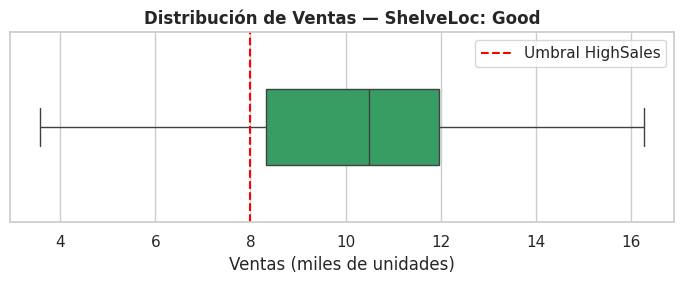

Good  → media=10.21, mediana=10.50, min=3.58, max=16.27


In [145]:
# Boxplot: Ventas (Sales) — Tiendas con estantería GOOD (una sola variable)
df_good = df_sales[df_sales['ShelveLoc'] == 'Good']

fig, ax = plt.subplots(figsize=(7, 3))
sns.boxplot(x=df_good['Sales'], color='#27AE60', width=0.4, ax=ax)
ax.axvline(x=8, color='red', linestyle='--', linewidth=1.5, label='Umbral HighSales')
ax.set_title('Distribución de Ventas — ShelveLoc: Good', fontsize=12, fontweight='bold')
ax.set_xlabel('Ventas (miles de unidades)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Good  → media={df_good['Sales'].mean():.2f}, mediana={df_good['Sales'].median():.2f}, min={df_good['Sales'].min():.2f}, max={df_good['Sales'].max():.2f}")

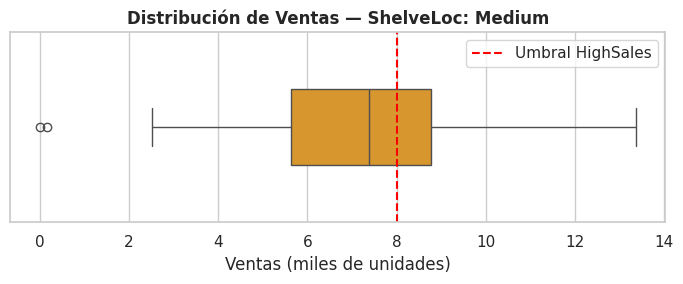

Medium → media=7.31, mediana=7.38, min=0.00, max=13.36


In [146]:
# Boxplot: Ventas (Sales) — Tiendas con estantería MEDIUM (una sola variable)
df_medium = df_sales[df_sales['ShelveLoc'] == 'Medium']

fig, ax = plt.subplots(figsize=(7, 3))
sns.boxplot(x=df_medium['Sales'], color='#F39C12', width=0.4, ax=ax)
ax.axvline(x=8, color='red', linestyle='--', linewidth=1.5, label='Umbral HighSales')
ax.set_title('Distribución de Ventas — ShelveLoc: Medium', fontsize=12, fontweight='bold')
ax.set_xlabel('Ventas (miles de unidades)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Medium → media={df_medium['Sales'].mean():.2f}, mediana={df_medium['Sales'].median():.2f}, min={df_medium['Sales'].min():.2f}, max={df_medium['Sales'].max():.2f}")

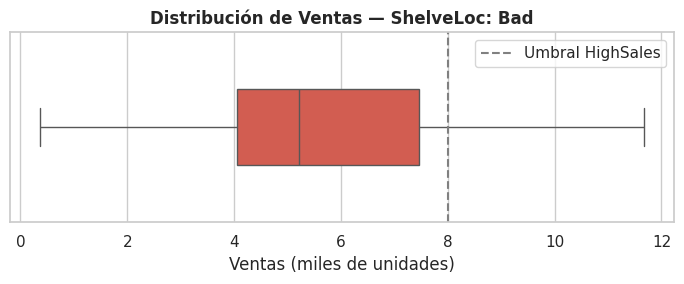

Bad   → media=5.52, mediana=5.21, min=0.37, max=11.67


In [147]:
# Boxplot: Ventas (Sales) — Tiendas con estantería BAD (una sola variable)
df_bad = df_sales[df_sales['ShelveLoc'] == 'Bad']

fig, ax = plt.subplots(figsize=(7, 3))
sns.boxplot(x=df_bad['Sales'], color='#E74C3C', width=0.4, ax=ax)
ax.axvline(x=8, color='gray', linestyle='--', linewidth=1.5, label='Umbral HighSales')
ax.set_title('Distribución de Ventas — ShelveLoc: Bad', fontsize=12, fontweight='bold')
ax.set_xlabel('Ventas (miles de unidades)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Bad   → media={df_bad['Sales'].mean():.2f}, mediana={df_bad['Sales'].median():.2f}, min={df_bad['Sales'].min():.2f}, max={df_bad['Sales'].max():.2f}")

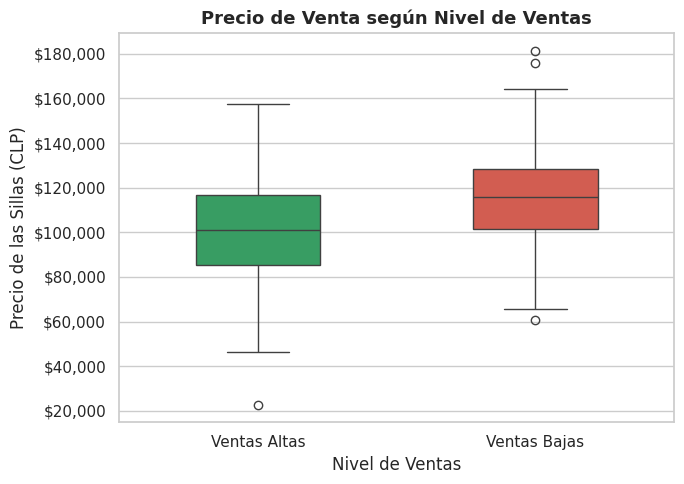

                       mean       50%      min       max
Nivel Ventas                                            
Ventas Altas  100717.378049  101175.0  22800.0  157700.0
Ventas Bajas  116459.533898  115900.0  60800.0  181450.0


In [148]:
# Boxplot: Precio (CLP) por Nivel de Ventas
# Analiza UNA variable numérica (Price) segmentada por la variable objetivo
# Se usa df_sales que tiene los valores ya convertidos a CLP
df_sales['Nivel Ventas'] = df_sales['HighSales'].map({1: 'Ventas Altas', 0: 'Ventas Bajas'})

# Verificar que Price tiene valores reales
assert df_sales['Price'].max() > 1000, "Price parece estar en USD o en cero — revisar transformación"

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_sales, x='Nivel Ventas', y='Price',
            palette={'Ventas Altas': '#27AE60', 'Ventas Bajas': '#E74C3C'},
            width=0.45, ax=ax)
ax.set_title('Precio de Venta según Nivel de Ventas', fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de Ventas')
ax.set_ylabel('Precio de las Sillas (CLP)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()
print(df_sales.groupby('Nivel Ventas')['Price'].describe()[['mean','50%','min','max']])

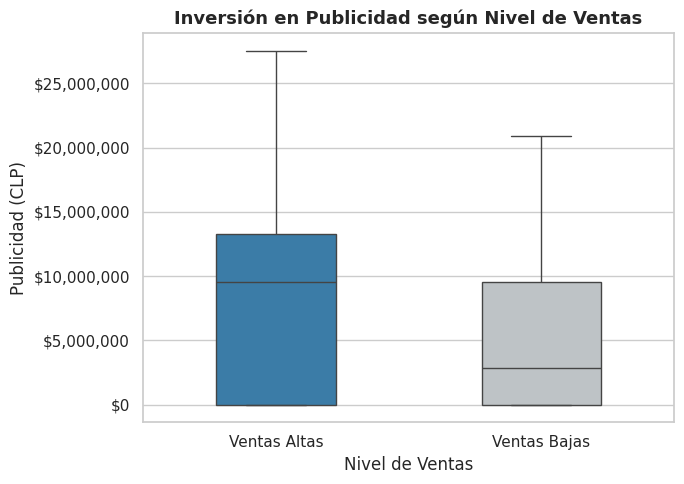

                      mean        50%  min         max
Nivel Ventas                                          
Ventas Altas  8.521037e+06  9500000.0  0.0  27550000.0
Ventas Bajas  4.762076e+06  2850000.0  0.0  20900000.0


In [149]:
# Boxplot: Publicidad (CLP) por Nivel de Ventas
# Analiza UNA variable numérica (Advertising) segmentada por la variable objetivo
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_sales, x='Nivel Ventas', y='Advertising',
            palette={'Ventas Altas': '#2980B9', 'Ventas Bajas': '#BDC3C7'},
            width=0.45, ax=ax)
ax.set_title('Inversión en Publicidad según Nivel de Ventas', fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de Ventas')
ax.set_ylabel('Publicidad (CLP)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()
print(df_sales.groupby('Nivel Ventas')['Advertising'].describe()[['mean','50%','min','max']])

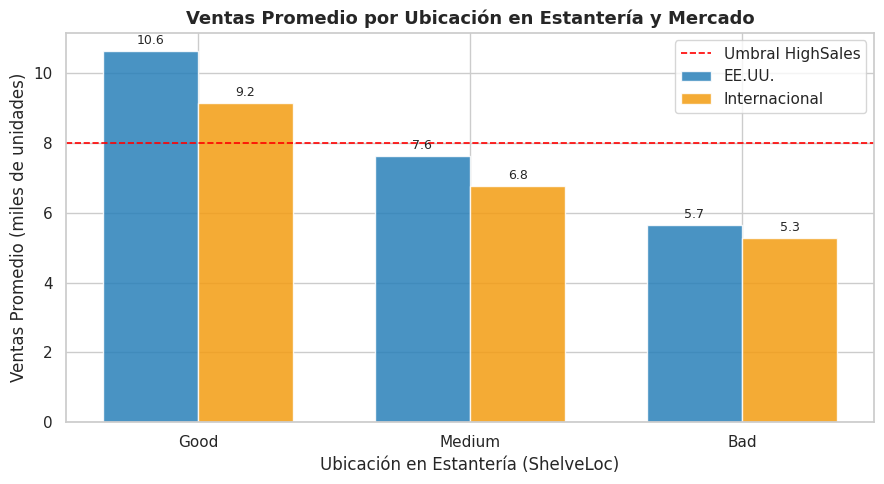

In [150]:
# Barras: Ventas promedio por Ubicación en Estantería y Mercado (US)
ventas_shelve_us = df_sales.groupby(['ShelveLoc', 'US'])['Sales'].mean().reset_index()
ventas_shelve_us.columns = ['ShelveLoc', 'Mercado', 'Ventas Promedio']
ventas_shelve_us['Mercado'] = ventas_shelve_us['Mercado'].map({'Yes': 'EE.UU.', 'No': 'Internacional'})

fig, ax = plt.subplots(figsize=(9, 5))
orden = ['Good', 'Medium', 'Bad']
x = range(len(orden))
width = 0.35
us_data  = ventas_shelve_us[ventas_shelve_us['Mercado'] == 'EE.UU.'].set_index('ShelveLoc')['Ventas Promedio']
int_data = ventas_shelve_us[ventas_shelve_us['Mercado'] == 'Internacional'].set_index('ShelveLoc')['Ventas Promedio']

bars1 = ax.bar([i - width/2 for i in x], [us_data.get(s, 0) for s in orden],
               width, label='EE.UU.', color='#2980B9', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], [int_data.get(s, 0) for s in orden],
               width, label='Internacional', color='#F39C12', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(orden)
ax.set_title('Ventas Promedio por Ubicación en Estantería y Mercado', fontsize=13, fontweight='bold')
ax.set_xlabel('Ubicación en Estantería (ShelveLoc)')
ax.set_ylabel('Ventas Promedio (miles de unidades)')
ax.axhline(y=8, color='red', linestyle='--', linewidth=1.2, label='Umbral HighSales')
ax.legend()
ax.bar_label(bars1, fmt='%.1f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.1f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

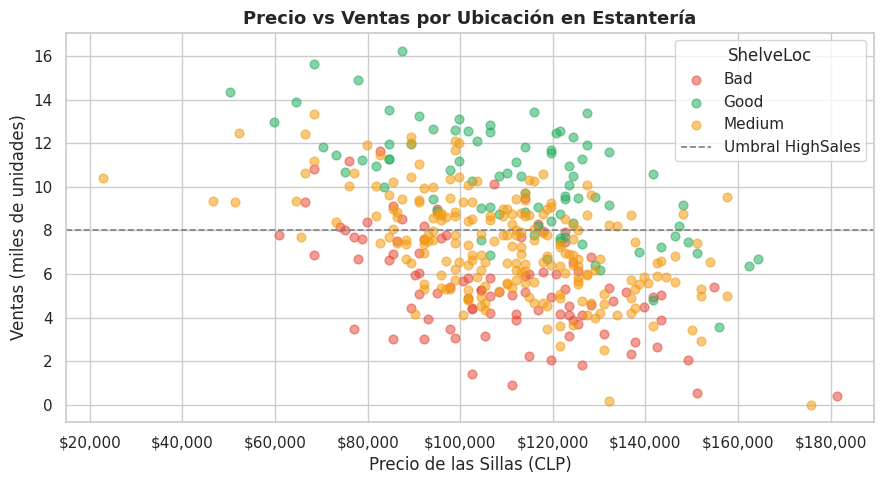

In [151]:
# Scatter: Precio vs Ventas coloreado por Ubicación en Estantería
fig, ax = plt.subplots(figsize=(9, 5))
colores = {'Good': '#27AE60', 'Medium': '#F39C12', 'Bad': '#E74C3C'}
for cat, grupo in df_sales.groupby('ShelveLoc'):
    ax.scatter(grupo['Price'], grupo['Sales'], c=colores[cat],
               label=cat, alpha=0.55, s=40)
ax.axhline(y=8, color='gray', linestyle='--', linewidth=1.2, label='Umbral HighSales')
ax.set_title('Precio vs Ventas por Ubicación en Estantería', fontsize=13, fontweight='bold')
ax.set_xlabel('Precio de las Sillas (CLP)')
ax.set_ylabel('Ventas (miles de unidades)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='ShelveLoc')
plt.tight_layout()
plt.show()

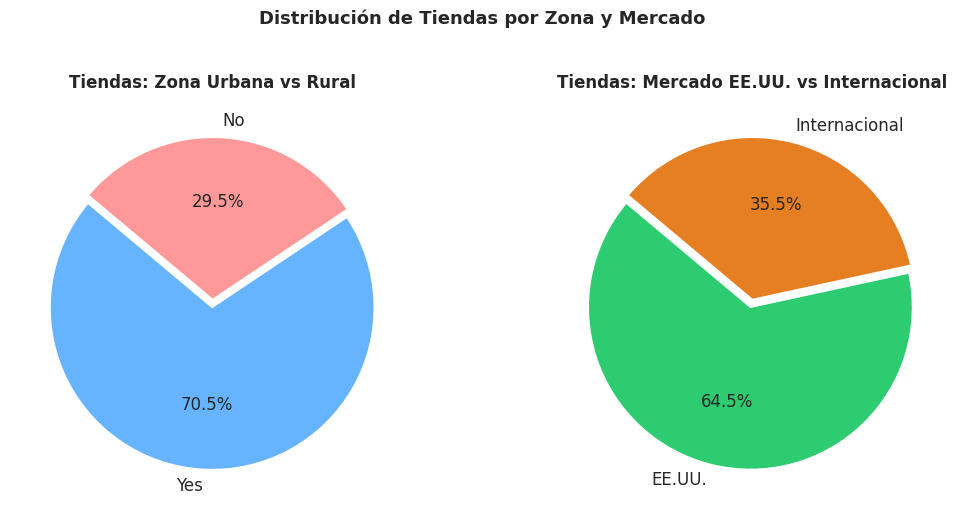

In [152]:
# Gráfico de torta: Proporción Urbana vs Rural
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Pie Urban
conteos_urban = df_sales['Urban'].value_counts()
axes[0].pie(conteos_urban, labels=conteos_urban.index, autopct='%1.1f%%',
            startangle=140, colors=['#66b3ff', '#ff9999'],
            explode=(0.05, 0), textprops={'fontsize': 12})
axes[0].set_title('Tiendas: Zona Urbana vs Rural', fontsize=12, fontweight='bold')

# Pie US
conteos_us = df_sales['US'].value_counts()
axes[1].pie(conteos_us, labels=['EE.UU.' if l=='Yes' else 'Internacional' for l in conteos_us.index],
            autopct='%1.1f%%', startangle=140, colors=['#2ecc71', '#e67e22'],
            explode=(0.05, 0), textprops={'fontsize': 12})
axes[1].set_title('Tiendas: Mercado EE.UU. vs Internacional', fontsize=12, fontweight='bold')

plt.suptitle('Distribución de Tiendas por Zona y Mercado', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

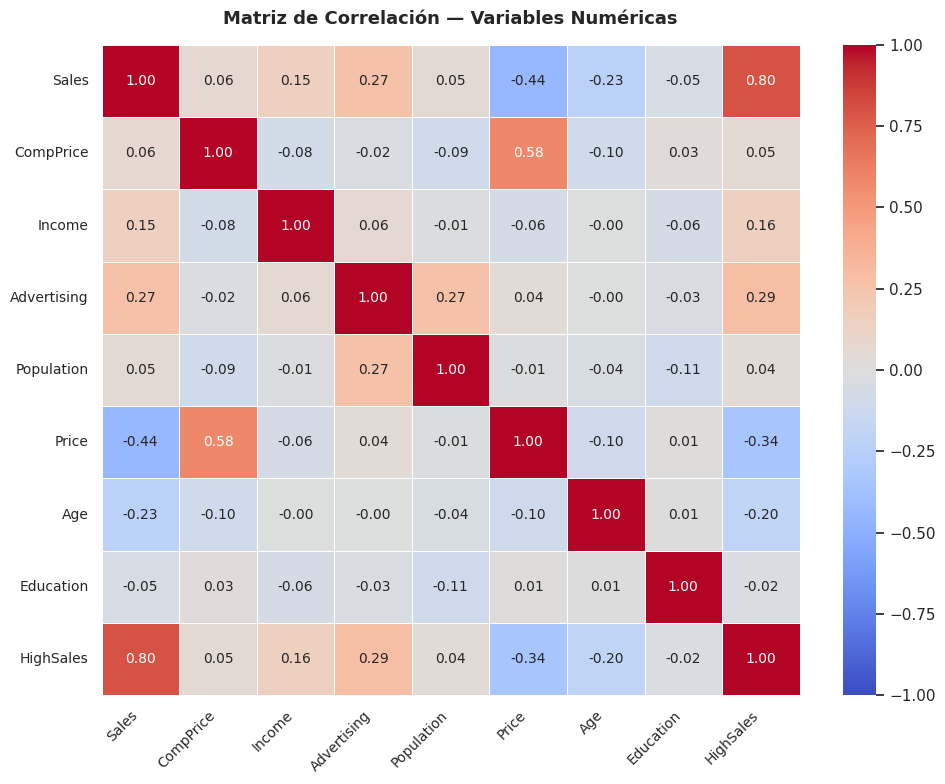


Correlaciones con Sales (ordenadas por valor absoluto):
HighSales      0.801641
Price          0.444951
Advertising    0.269507
Age            0.231815
Income         0.151951
CompPrice      0.064079
Education      0.051955
Population     0.050471

Correlaciones con HighSales (ordenadas por valor absoluto):
Sales          0.801641
Price          0.344653
Advertising    0.292995
Age            0.197882
Income         0.156062
CompPrice      0.054463
Population     0.043451
Education      0.024471


In [153]:
# Matriz de Correlación — variables numéricas relevantes (excluye columnas auxiliares)
cols_numericas = ['Sales', 'CompPrice', 'Income', 'Advertising',
                  'Population', 'Price', 'Age', 'Education', 'HighSales']
cols_numericas = [c for c in cols_numericas if c in df_sales.columns]

corr = df_sales[cols_numericas].corr()

# Verificar que no hay columnas NaN completas (indicaría transformación fallida)
cols_nan = corr.columns[corr.isna().all()].tolist()
if cols_nan:
    print(f"ADVERTENCIA: Estas columnas tienen correlaciones NaN (probablemente transformación fallida): {cols_nan}")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    vmin=-1, vmax=1,
    annot_kws={'size': 10},
    ax=ax
)
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("\nCorrelaciones con Sales (ordenadas por valor absoluto):")
sales_corr = corr['Sales'].drop('Sales').dropna()
print(sales_corr.abs().sort_values(ascending=False).to_string())
print("\nCorrelaciones con HighSales (ordenadas por valor absoluto):")
hs_corr = corr['HighSales'].drop('HighSales').dropna()
print(hs_corr.abs().sort_values(ascending=False).to_string())

# 4. Preparación de Datos: Label Encoding y Estandarización

> ## Label Encoding
Se aplica **Label Encoding** a las variables binarias `Urban` y `US` (Yes/No → 1/0), tal como indica la pauta.
Para `ShelveLoc` (3 categorías: Good, Medium, Bad) se usa `get_dummies` para evitar asignar un orden artificial.

In [154]:
# Limpiar columnas auxiliares del EDA antes de preparar para ML
cols_aux = ['Nivel Ventas']
df_sales_ml = df_sales.drop(columns=[c for c in cols_aux if c in df_sales.columns])

# 1. Copiar el dataframe limpio
df_prep = df_sales_ml.copy()

if 'Unnamed: 0' in df_prep.columns:
    df_prep = df_prep.drop(columns=['Unnamed: 0'])

# 2. Label Encoding — solo en Urban y US (variables binarias Yes/No)
#    ShelveLoc tiene 3 categorías ordinales y se deja para get_dummies si fuera necesario,
#    pero en este modelo se mantiene como string y se eliminará al armar X,
#    o se puede encodear aquí como ordinal. Según la pauta: Urban y US.
le = LabelEncoder()
cols_le = ['Urban', 'US']   # ← solo Urban y US según la pauta

for col in cols_le:
    df_prep[col] = le.fit_transform(df_prep[col])

# ShelveLoc es categórica con 3 niveles → usar pd.get_dummies para evitar orden artificial
df_prep = pd.get_dummies(df_prep, columns=['ShelveLoc'], drop_first=True)

# Verificar que no quedan columnas de texto
cols_texto = df_prep.select_dtypes(include='object').columns.tolist()
if cols_texto:
    print(f"ADVERTENCIA — columnas de texto restantes: {cols_texto}")
else:
    print("OK — todas las columnas son numéricas")

print("\n--- Muestra tras Label Encoding (Urban, US) y dummies (ShelveLoc) ---")
display(df_prep[['Urban', 'US', 'ShelveLoc_Good', 'ShelveLoc_Medium']].head())

OK — todas las columnas son numéricas

--- Muestra tras Label Encoding (Urban, US) y dummies (ShelveLoc) ---


,Urban,US,ShelveLoc_Good,ShelveLoc_Medium
0,1,1,False,False
1,1,1,True,False
2,1,1,False,True
3,1,1,False,True
4,1,0,False,False


> ## Estandarización y Separación
Se estandariza **antes** de dividir el dataset, tal como indica la pauta.

In [155]:
# 3. Variables predictoras (X) y objetivo (y)
# Se excluye 'Sales' para evitar data leakage; 'HighSales' es la variable objetivo.
X = df_prep.drop(columns=['Sales', 'HighSales'])
y = df_prep['HighSales']

# Verificar que X es 100% numérico antes de escalar
assert X.select_dtypes(include='object').empty, (
    f"Columnas de texto en X: {X.select_dtypes(include='object').columns.tolist()}"
)

# 4. Estandarización ANTES de la división (requisito de la pauta)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Dimensiones de X: {X.shape}")
print(f"Columnas usadas como predictores: {list(X.columns)}")
print("\n--- Muestra de Datos Estandarizados (X_scaled) ---")
display(X_scaled.head())

Dimensiones de X: (400, 11)
Columnas usadas como predictores: ['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education', 'Urban', 'US', 'ShelveLoc_Good', 'ShelveLoc_Medium']

--- Muestra de Datos Estandarizados (X_scaled) ---


,CompPrice,Income,Advertising,Population,Price,Age,Education,Urban,US,ShelveLoc_Good,ShelveLoc_Medium
0,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,1.184449,0.646869,0.741881,-0.519462,-1.099975
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,-1.490113,0.646869,0.741881,1.925067,-1.099975
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,-0.725953,0.646869,0.741881,-0.519462,0.909112
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,0.038208,0.646869,0.741881,-0.519462,0.909112
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,-0.343872,0.646869,-1.347925,-0.519462,-1.099975


In [156]:
# 5. División en Entrenamiento y Prueba (80/20)
# stratify=y mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensiones Entrenamiento: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Dimensiones Prueba:        X_test={X_test.shape},  y_test={y_test.shape}")

Dimensiones Entrenamiento: X_train=(320, 11), y_train=(320,)
Dimensiones Prueba:        X_test=(80, 11),  y_test=(80,)


# 5. Cargar

Se guarda el dataset limpio para ser utilizado posteriormente por el Dashboard interactivo.

In [157]:
# Guardar el archivo limpio
df_sales.to_csv('dataset_car_seats_clean.csv', index=False)
print("Datos cargados y guardados como 'dataset_car_seats_clean.csv'.")

Datos cargados y guardados como 'dataset_car_seats_clean.csv'.


# 6. Modelado de Aprendizaje Automático

Se comparan dos modelos para predecir si las ventas de una tienda serán altas (`HighSales=1`) o bajas (`HighSales=0`).

> ## Modelo 1: Árbol de Decisión

In [158]:
print("=" * 50)
print("MODELO 1: ÁRBOL DE DECISIÓN")
print("=" * 50)

# Hiperparámetros a explorar
parametros_dt = {
    'max_depth':        [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion':        ['gini', 'entropy']
}

modelo_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    parametros_dt, cv=5, scoring='accuracy'
)
modelo_dt.fit(X_train, y_train)

# Predicciones
y_pred_dt = modelo_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Mejores hiperparámetros:", modelo_dt.best_params_)
print(f"Exactitud (Accuracy):    {acc_dt:.4f}")

# Predicción por cada clase (precision, recall, f1 por clase)
print("\nPredicción detallada por CADA clase (0 = Ventas Bajas, 1 = Ventas Altas):")
print(classification_report(y_test, y_pred_dt,
                             target_names=['Ventas Bajas (0)', 'Ventas Altas (1)']))

MODELO 1: ÁRBOL DE DECISIÓN
Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Exactitud (Accuracy):    0.7500

Predicción detallada por CADA clase (0 = Ventas Bajas, 1 = Ventas Altas):
                  precision    recall  f1-score   support

Ventas Bajas (0)       0.81      0.74      0.78        47
Ventas Altas (1)       0.68      0.76      0.71        33

        accuracy                           0.75        80
       macro avg       0.74      0.75      0.75        80
    weighted avg       0.76      0.75      0.75        80



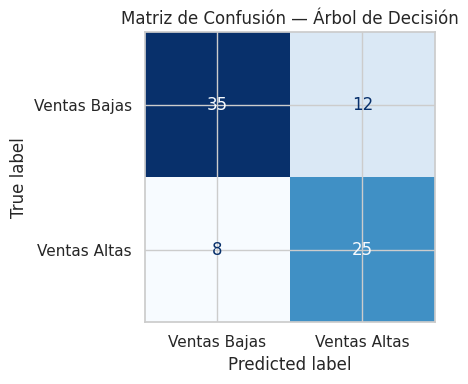

In [159]:
# Matriz de Confusión — Árbol de Decisión
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                                  display_labels=['Ventas Bajas', 'Ventas Altas'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_dt.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Árbol de Decisión')
plt.tight_layout()
plt.show()

> ## Modelo 2: Regresión Logística

In [160]:
print("=" * 50)
print("MODELO 2: REGRESIÓN LOGÍSTICA")
print("=" * 50)

parametros_lr = {
    'C':      [0.1, 1, 10],
    'solver': ['liblinear']
}

modelo_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    parametros_lr, cv=5, scoring='accuracy'
)
modelo_lr.fit(X_train, y_train)

# Predicciones
y_pred_lr = modelo_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Mejores hiperparámetros:", modelo_lr.best_params_)
print(f"Exactitud (Accuracy):    {acc_lr:.4f}")

# Predicción por cada clase
print("\nPredicción detallada por CADA clase (0 = Ventas Bajas, 1 = Ventas Altas):")
print(classification_report(y_test, y_pred_lr,
                             target_names=['Ventas Bajas (0)', 'Ventas Altas (1)']))

MODELO 2: REGRESIÓN LOGÍSTICA
Mejores hiperparámetros: {'C': 10, 'solver': 'liblinear'}
Exactitud (Accuracy):    0.9125

Predicción detallada por CADA clase (0 = Ventas Bajas, 1 = Ventas Altas):
                  precision    recall  f1-score   support

Ventas Bajas (0)       0.93      0.91      0.92        47
Ventas Altas (1)       0.88      0.91      0.90        33

        accuracy                           0.91        80
       macro avg       0.91      0.91      0.91        80
    weighted avg       0.91      0.91      0.91        80



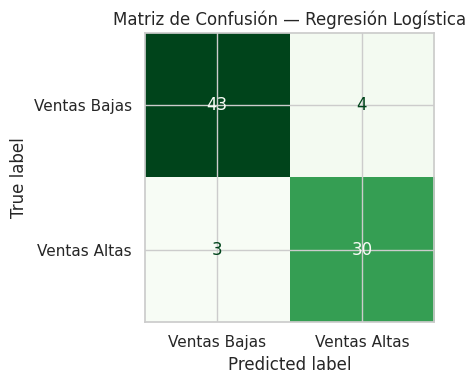

In [161]:
# Matriz de Confusión — Regresión Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                                  display_labels=['Ventas Bajas', 'Ventas Altas'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_lr.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusión — Regresión Logística')
plt.tight_layout()
plt.show()

> ## Comparación de Modelos

In [162]:
print("=" * 50)
print("COMPARACIÓN DE MODELOS")
print("=" * 50)
print(f"Árbol de Decisión:   {acc_dt:.4f}")
print(f"Regresión Logística: {acc_lr:.4f}")

if acc_dt > acc_lr:
    mejor = "Árbol de Decisión"
    razon = "mayor capacidad predictiva medida por exactitud en los datos de prueba."
else:
    mejor = "Regresión Logística"
    razon = "mayor o igual exactitud y mejor interpretabilidad a través de sus coeficientes."

print(f"\nConclusión: {mejor} es el modelo recomendado — presenta {razon}")

COMPARACIÓN DE MODELOS
Árbol de Decisión:   0.7500
Regresión Logística: 0.9125

Conclusión: Regresión Logística es el modelo recomendado — presenta mayor o igual exactitud y mejor interpretabilidad a través de sus coeficientes.


# 7. Dashboard Interactivo con Plotly Dash

Se construye un dashboard interactivo que permite explorar el dataset de Car Seats desde distintos ángulos de análisis. Primero se definen los gráficos y luego se configura el Dashboard, siguiendo la lógica del archivo de referencia.

## Gráficos del Dashboard

In [163]:
# Cargar el dataset procesado
df = pd.read_csv('dataset_car_seats_clean.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Etiqueta legible
df['Nivel de Ventas'] = df['HighSales'].map({1: 'Ventas Altas', 0: 'Ventas Bajas'})

import plotly.express as px

COLORS = {
    'primary':   '#2C3E50',
    'secondary': '#2980B9',
    'accent':    '#E74C3C',
    'success':   '#27AE60',
    'warning':   '#F39C12',
    'bg':        '#F4F6F9',
    'card':      '#FFFFFF',
    'text':      '#2C3E50',
    'muted':     '#7F8C8D',
}

SHELVE_COLORS = {'Good': COLORS['success'], 'Medium': COLORS['warning'], 'Bad': COLORS['accent']}

In [164]:
# Gráfico 1: Histograma distribución de ventas
fig_hist = px.histogram(
    df, x='Sales', nbins=25,
    color='Nivel de Ventas',
    color_discrete_map={'Ventas Altas': COLORS['success'], 'Ventas Bajas': COLORS['accent']},
    title='Distribución de Ventas por Tienda',
    labels={'Sales': 'Ventas (miles de unidades)', 'count': 'Tiendas'},
    barmode='overlay', opacity=0.75,
)
fig_hist.add_vline(x=8, line_dash='dash', line_color=COLORS['warning'],
                   annotation_text='Umbral HighSales', annotation_position='top right',
                   annotation_font_color=COLORS['warning'])
fig_hist.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                        legend_title='', margin=dict(t=48, b=32, l=8, r=8))
fig_hist.show()

In [165]:
# Gráfico 2: Proporción Ventas Altas vs Bajas (pastel)
counts = df['Nivel de Ventas'].value_counts().reset_index()
counts.columns = ['Nivel', 'Tiendas']
fig_pie = px.pie(
    counts, names='Nivel', values='Tiendas',
    title='Proporción de Tiendas con Ventas Altas vs Bajas',
    color='Nivel',
    color_discrete_map={'Ventas Altas': COLORS['success'], 'Ventas Bajas': COLORS['accent']},
    hole=0.42,
)
fig_pie.update_traces(textposition='outside', textinfo='percent+label')
fig_pie.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                       showlegend=False, margin=dict(t=48, b=32, l=8, r=8))
fig_pie.show()

In [166]:
# Gráfico 3: Boxplot ventas por ShelveLoc
fig_box = px.box(
    df, x='ShelveLoc', y='Sales',
    color='ShelveLoc', color_discrete_map=SHELVE_COLORS,
    category_orders={'ShelveLoc': ['Good', 'Medium', 'Bad']},
    title='Ventas según Ubicación en Estantería',
    labels={'Sales': 'Ventas (miles)', 'ShelveLoc': 'Ubicación'},
    points='outliers',
)
fig_box.add_hline(y=8, line_dash='dash', line_color=COLORS['warning'],
                   annotation_text='Umbral HighSales')
fig_box.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                       showlegend=False, margin=dict(t=48, b=32, l=8, r=8))
fig_box.show()

In [167]:
# Gráfico 4: Precio vs Ventas (scatter con tendencia)
fig_scatter_price = px.scatter(
    df, x='Price', y='Sales',
    color='Nivel de Ventas',
    color_discrete_map={'Ventas Altas': COLORS['success'], 'Ventas Bajas': COLORS['accent']},
    trendline='ols',
    title='Precio vs Ventas',
    labels={'Price': 'Precio (CLP)', 'Sales': 'Ventas (miles)'},
    opacity=0.65,
    hover_data={'ShelveLoc': True, 'Urban': True},
)
fig_scatter_price.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                                  legend_title='', margin=dict(t=48, b=32, l=8, r=8))
fig_scatter_price.show()

In [168]:
# Gráfico 5: Publicidad vs Ventas
fig_scatter_adv = px.scatter(
    df, x='Advertising', y='Sales',
    color='ShelveLoc', color_discrete_map=SHELVE_COLORS,
    size='Price', size_max=18,
    title='Inversión en Publicidad vs Ventas',
    labels={'Advertising': 'Publicidad (CLP)', 'Sales': 'Ventas (miles)', 'ShelveLoc': 'Estantería'},
    opacity=0.7,
)
fig_scatter_adv.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                               legend_title='Estantería', margin=dict(t=48, b=32, l=8, r=8))
fig_scatter_adv.show()

In [169]:
# Gráfico 6: Venta promedio por Mercado y Zona
grp = df.groupby(['US', 'Urban'])['Sales'].mean().reset_index()
grp['Mercado'] = grp['US'].map({'Yes': 'EE.UU.', 'No': 'Internacional'})
grp['Zona']    = grp['Urban'].map({'Yes': 'Urbana', 'No': 'Rural'})
fig_bar_market = px.bar(
    grp, x='Mercado', y='Sales', color='Zona', barmode='group',
    color_discrete_map={'Urbana': COLORS['secondary'], 'Rural': COLORS['warning']},
    title='Venta Promedio por Mercado y Zona',
    labels={'Sales': 'Ventas promedio (miles)', 'Mercado': 'Mercado'},
    text_auto='.2f',
)
fig_bar_market.update_traces(textposition='outside')
fig_bar_market.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                               legend_title='Zona', margin=dict(t=48, b=32, l=8, r=8))
fig_bar_market.show()

## Configurando el Dashboard de Dash

In [170]:
import dash
from dash import dcc, html, Input, Output
import threading

# Inicializar la aplicación Dash
app = dash.Dash(__name__)

# Layout: primero los gráficos pre-construidos, luego los interactivos con filtros
app.layout = html.Div(
    style={'backgroundColor': COLORS['bg'], 'fontFamily': 'Segoe UI, Arial, sans-serif',
           'minHeight': '100vh'},
    children=[

        # Encabezado
        html.Div(
            style={'backgroundColor': COLORS['primary'], 'padding': '24px 40px',
                   'marginBottom': '24px'},
            children=[
                html.H1('Dashboard de Ventas — Car Seats',
                        style={'color': '#FFFFFF', 'margin': 0, 'fontSize': '26px',
                               'fontWeight': '700'}),
                html.P('Análisis exploratorio interactivo · Programación para la Ciencia de Datos',
                       style={'color': '#BDC3C7', 'margin': '6px 0 0', 'fontSize': '13px'}),
            ]
        ),

        # ── Sección 1: Gráficos estáticos pre-construidos ───────────────────
        html.Div(style={'margin': '0 32px 24px'},
                 children=[html.H2('Análisis General',
                                   style={'color': COLORS['text'], 'fontSize': '18px',
                                          'fontWeight': '600', 'marginBottom': '16px'})]),

        html.Div(
            style={'display': 'flex', 'gap': '20px', 'margin': '0 32px 20px', 'flexWrap': 'wrap'},
            children=[
                html.Div(dcc.Graph(figure=fig_hist),
                         style={'flex': '1', 'minWidth': '340px', 'backgroundColor': COLORS['card'],
                                'borderRadius': '8px', 'boxShadow': '0 2px 8px rgba(0,0,0,0.07)',
                                'padding': '16px'}),
                html.Div(dcc.Graph(figure=fig_pie),
                         style={'flex': '0 0 360px', 'backgroundColor': COLORS['card'],
                                'borderRadius': '8px', 'boxShadow': '0 2px 8px rgba(0,0,0,0.07)',
                                'padding': '16px'}),
            ]
        ),

        html.Div(
            style={'display': 'flex', 'gap': '20px', 'margin': '0 32px 20px', 'flexWrap': 'wrap'},
            children=[
                html.Div(dcc.Graph(figure=fig_box),
                         style={'flex': '1', 'minWidth': '340px', 'backgroundColor': COLORS['card'],
                                'borderRadius': '8px', 'boxShadow': '0 2px 8px rgba(0,0,0,0.07)',
                                'padding': '16px'}),
                html.Div(dcc.Graph(figure=fig_scatter_price),
                         style={'flex': '1', 'minWidth': '340px', 'backgroundColor': COLORS['card'],
                                'borderRadius': '8px', 'boxShadow': '0 2px 8px rgba(0,0,0,0.07)',
                                'padding': '16px'}),
            ]
        ),

        html.Div(
            style={'display': 'flex', 'gap': '20px', 'margin': '0 32px 32px', 'flexWrap': 'wrap'},
            children=[
                html.Div(dcc.Graph(figure=fig_scatter_adv),
                         style={'flex': '1', 'minWidth': '340px', 'backgroundColor': COLORS['card'],
                                'borderRadius': '8px', 'boxShadow': '0 2px 8px rgba(0,0,0,0.07)',
                                'padding': '16px'}),
                html.Div(dcc.Graph(figure=fig_bar_market),
                         style={'flex': '1', 'minWidth': '340px', 'backgroundColor': COLORS['card'],
                                'borderRadius': '8px', 'boxShadow': '0 2px 8px rgba(0,0,0,0.07)',
                                'padding': '16px'}),
            ]
        ),

        # ── Sección 2: Filtros interactivos ────────────────────────────────
        html.Div(
            style={'backgroundColor': COLORS['card'], 'borderRadius': '8px',
                   'padding': '20px 32px', 'margin': '0 32px 24px',
                   'boxShadow': '0 2px 8px rgba(0,0,0,0.08)'},
            children=[
                html.H3('Filtros Interactivos', style={'color': COLORS['text'], 'marginTop': 0,
                                                        'fontSize': '15px', 'fontWeight': '600',
                                                        'marginBottom': '16px'}),
                html.Div(
                    style={'display': 'flex', 'gap': '32px', 'flexWrap': 'wrap'},
                    children=[
                        html.Div([
                            html.Label('Ubicación en estantería',
                                       style={'fontSize': '12px', 'color': COLORS['muted'],
                                              'fontWeight': '600', 'display': 'block',
                                              'marginBottom': '6px', 'textTransform': 'uppercase'}),
                            dcc.Checklist(
                                id='filter-shelve',
                                options=[{'label': f' {v}', 'value': v} for v in ['Good', 'Medium', 'Bad']],
                                value=['Good', 'Medium', 'Bad'],
                                inline=True,
                                style={'fontSize': '14px'},
                                inputStyle={'marginRight': '4px'},
                            )
                        ], style={'minWidth': '240px'}),

                        html.Div([
                            html.Label('Zona',
                                       style={'fontSize': '12px', 'color': COLORS['muted'],
                                              'fontWeight': '600', 'display': 'block',
                                              'marginBottom': '6px', 'textTransform': 'uppercase'}),
                            dcc.RadioItems(
                                id='filter-urban',
                                options=[{'label': ' Todas', 'value': 'all'},
                                         {'label': ' Urbana', 'value': 'Yes'},
                                         {'label': ' Rural', 'value': 'No'}],
                                value='all', inline=True,
                                style={'fontSize': '14px'}, inputStyle={'marginRight': '4px'},
                            )
                        ], style={'minWidth': '200px'}),

                        html.Div([
                            html.Label('Mercado',
                                       style={'fontSize': '12px', 'color': COLORS['muted'],
                                              'fontWeight': '600', 'display': 'block',
                                              'marginBottom': '6px', 'textTransform': 'uppercase'}),
                            dcc.RadioItems(
                                id='filter-us',
                                options=[{'label': ' Todos', 'value': 'all'},
                                         {'label': ' EE.UU.', 'value': 'Yes'},
                                         {'label': ' Internacional', 'value': 'No'}],
                                value='all', inline=True,
                                style={'fontSize': '14px'}, inputStyle={'marginRight': '4px'},
                            )
                        ], style={'minWidth': '220px'}),
                    ]
                )
            ]
        ),

        # KPIs dinámicos
        html.Div(id='kpi-row',
                 style={'display': 'flex', 'gap': '16px', 'margin': '0 32px 24px',
                        'flexWrap': 'wrap'}),

        # Gráfico interactivo filtrado
        html.Div(
            style={'margin': '0 32px 40px'},
            children=[
                html.Div(dcc.Graph(id='interactive-bar'),
                         style={'backgroundColor': COLORS['card'], 'borderRadius': '8px',
                                'boxShadow': '0 2px 8px rgba(0,0,0,0.07)', 'padding': '16px'}),
            ]
        ),
    ]
)


# ── Callbacks ─────────────────────────────────────────────────────────────────
def apply_filters(shelve_vals, urban_val, us_val):
    dff = df.copy()
    if shelve_vals:
        dff = dff[dff['ShelveLoc'].isin(shelve_vals)]
    if urban_val != 'all':
        dff = dff[dff['Urban'] == urban_val]
    if us_val != 'all':
        dff = dff[dff['US'] == us_val]
    return dff


@app.callback(
    Output('kpi-row', 'children'),
    Input('filter-shelve', 'value'),
    Input('filter-urban',  'value'),
    Input('filter-us',     'value'),
)
def update_kpis(shelve_vals, urban_val, us_val):
    dff   = apply_filters(shelve_vals, urban_val, us_val)
    total = len(dff)
    high  = int(dff['HighSales'].sum())
    kpis  = [
        ('Tiendas', f'{total:,}',                                      COLORS['secondary']),
        ('Ventas Altas', f'{high:,}',                                  COLORS['success']),
        ('% Ventas Altas', f'{high/total*100:.1f}%' if total else '—', COLORS['warning']),
        ('Venta Promedio', f'{dff["Sales"].mean():.2f} miles' if total else '—', COLORS['primary']),
        ('Precio Promedio', f'${dff["Price"].mean():,.0f} CLP' if total else '—', COLORS['accent']),
    ]
    return [
        html.Div(style={'backgroundColor': COLORS['card'], 'borderRadius': '8px',
                        'padding': '16px 24px', 'flex': '1', 'minWidth': '150px',
                        'boxShadow': '0 2px 8px rgba(0,0,0,0.07)',
                        'borderTop': f'4px solid {color}'},
                 children=[html.P(label, style={'margin': '0 0 4px', 'fontSize': '12px',
                                                 'color': COLORS['muted'], 'fontWeight': '600',
                                                 'textTransform': 'uppercase'}),
                            html.P(value, style={'margin': 0, 'fontSize': '22px',
                                                  'fontWeight': '700', 'color': color})])
        for label, value, color in kpis
    ]


@app.callback(
    Output('interactive-bar', 'figure'),
    Input('filter-shelve', 'value'),
    Input('filter-urban',  'value'),
    Input('filter-us',     'value'),
)
def update_interactive_bar(shelve_vals, urban_val, us_val):
    dff = apply_filters(shelve_vals, urban_val, us_val)
    grp = dff.groupby(['ShelveLoc', 'Nivel de Ventas'])['Sales'].mean().reset_index()
    fig = px.bar(grp, x='ShelveLoc', y='Sales', color='Nivel de Ventas', barmode='group',
                 color_discrete_map={'Ventas Altas': COLORS['success'], 'Ventas Bajas': COLORS['accent']},
                 title='Venta Promedio por Ubicación y Nivel de Ventas (filtrado)',
                 labels={'Sales': 'Venta promedio (miles)', 'ShelveLoc': 'Ubicación'},
                 text_auto='.2f')
    fig.update_traces(textposition='outside')
    fig.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                       legend_title='', margin=dict(t=48, b=32, l=8, r=8))
    fig.update_yaxes(showgrid=True, gridcolor='#ECEFF1')
    return fig


print("App Dash configurada correctamente.")

App Dash configurada correctamente.


## Configurando cloudflared para el Dashboard de Dash

Se usa cloudflared para generar una URL pública accesible desde Google Colab, siguiendo la misma lógica que el archivo de referencia.

In [171]:
# ── Ejecutar el Dashboard en Google Colab con cloudflared ───────────────────
import threading
import time
import subprocess

# Instalar cloudflared
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

# Correr el servidor Dash en segundo plano
def run():
    app.run(debug=False, port=8050)

thread = threading.Thread(target=run)
thread.daemon = True
thread.start()

# Esperar que el servidor levante
time.sleep(3)

# Crear túnel público
process = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:8050'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Esperar y mostrar la URL pública
time.sleep(5)
output = process.stderr.read1(2048).decode('utf-8')
for line in output.split('\n'):
    if 'trycloudflare.com' in line:
        url = line.split('|')[-1].strip() if '|' in line else line.strip()
        print(f"Dashboard disponible en: {url}")
        break

cloudflared: Text file busy
Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 8050 is in use by another program. Either identify and stop that program, or start the server with a different port.


Dashboard disponible en: 2026-06-24T01:47:54Z INF Requesting new quick Tunnel on trycloudflare.com...
